# Impact of $A$ on dipole + clustering map generation

The goal of this notebook is to generate the data to study the impact of A on the injected dipole measurement when a clustering effect is added.

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
import fitsio

from simulMap import *
from fitMap import *
from utile_fitsFile import *
from mappers import CountMapper
from generators import Generator

In [2]:
#sources:
NSource_px_th = int(1e6)
#print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

generator = Generator(nside = 64, nest = True)

Theorical number of sources in one pixel : 1000000


/home/victoria/miniconda3/envs/M2Stage/lib/python3.10/site-packages/pyccl/errors.py:22: CCLWarning: Nchi must be a positive integer. Setting to match tracer with fewest chi samples.
  warnings_builtin.warn(*args, **kwargs)
/home/victoria/miniconda3/envs/M2Stage/lib/python3.10/site-packages/pyccl/errors.py:22: CCLWarning: chi_min must be greater than zero.Setting to default 1e-6 Mpc.
  warnings_builtin.warn(*args, **kwargs)


## Dipole creation

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.9e+04 (χ²/ndof = 1.0)    │              Nfcn = 291              │
│ EDM = 2.69e-06 (Goal: 0.0002)    │            time = 2.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │1000.000e3 │  0.005e3  │  -0.005e3  │  0.005e3   │    0    │         │       │
│ 1 │ A    │ 9.999e-3  │ 0.008e-3  │ -0.008e-3  │  0.008e-3  │    0    │    1    │       │
│ 2 │ ra   │  168.08   │   0.05    │   -0.05    │    0.05    │    0    │   360   │       │
│ 3 │ dec  │   -7.12   │   0.04    │   -0.04    │    0.04    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -5     │     5     │   -8e-6   │   8e-6    │   -0.05   │   0.05    │   -0.04   │   0.04    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │     20.3  0.02e-9   -0.000   -0.000 │
│   A │  0.02e-9  6.1e-11 -0.01e-9 -0.01e-9 │
│  ra │   -0.000 -0.01e-9  0.00204   -0.000 │
│ dec │   -0.000 -0.01e-9   -0.000    0.002 │
└─────┴─────────────────────────────────────┘

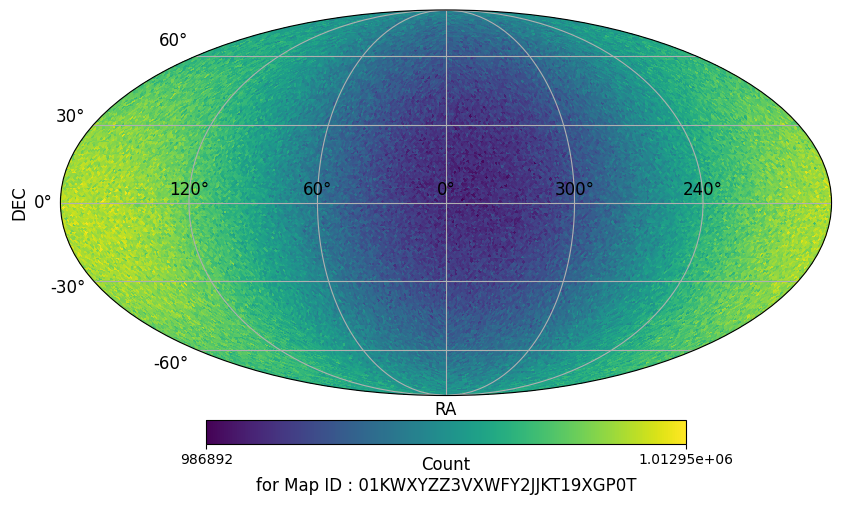

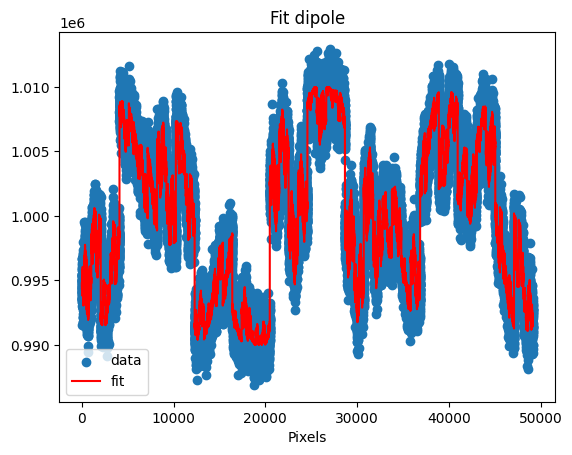

In [3]:
A, ra, dec = 0.01, 168, -7
dipoleMapper = generator.generate_dipoleContrast(A, ra, dec)
monopMapper = generator.generate_monopole(NSource_px_th, contrastMapper=dipoleMapper)
monopMapper = monopMapper.get_poisson_noise()

init =  (NSource_px_th, 1, 100, 0)
monopMapper.fit_dipole("", init)

## Blinding

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.668e+04 (χ²/ndof = 0.7)  │              Nfcn = 339              │
│ EDM = 7.52e-05 (Goal: 0.0002)    │            time = 2.7 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │1000.000e3 │  0.005e3  │  -0.005e3  │  0.005e3   │    0    │         │       │
│ 1 │ A    │ 17.419e-3 │ 0.008e-3  │ -0.008e-3  │  0.008e-3  │    0    │    1    │       │
│ 2 │ ra   │  16.637   │   0.026   │   -0.026   │   0.026    │    0    │   360   │       │
│ 3 │ dec  │  -4.957   │   0.026   │   -0.026   │   0.026    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -5     │     5     │   -8e-6   │   8e-6    │  -0.026   │   0.026   │  -0.026   │   0.026   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │     20.3  0.02e-9        0       -0 │
│   A │  0.02e-9  6.1e-11  0.01e-9 -0.01e-9 │
│  ra │        0  0.01e-9 0.000665        0 │
│ dec │       -0 -0.01e-9        0  0.00066 │
└─────┴─────────────────────────────────────┘

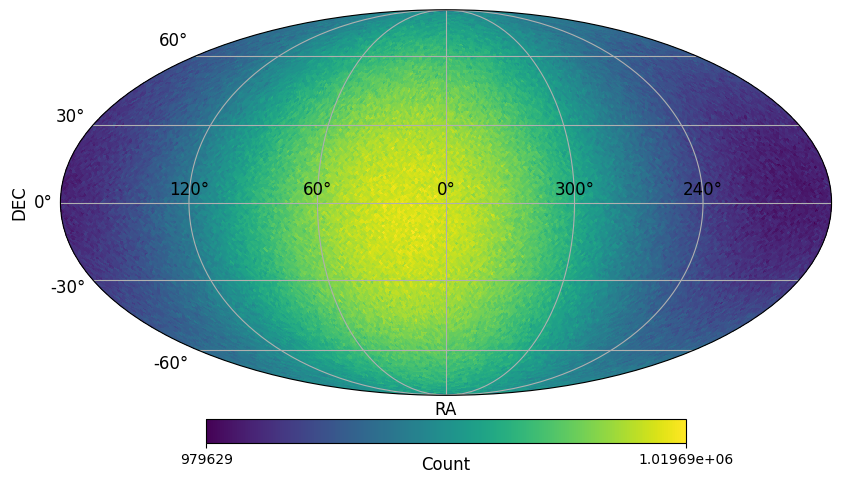

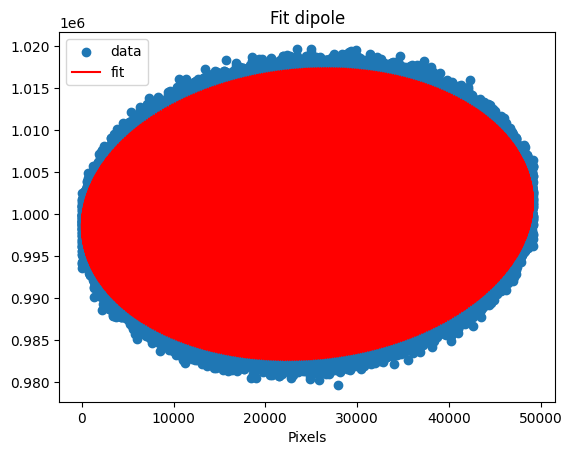

In [4]:
cl, alms = monopMapper.anafast(alm=True)
lmax = hp.Alm.getlmax(len(alms))

idx1, idx0, idx_1 = hp.Alm.getidx(lmax, 1, 1), hp.Alm.getidx(lmax, 1, 0), hp.Alm.getidx(lmax, 1, -1)
alms10_1 = np.array(alms[[idx1, idx0, idx_1]])
almsOrigin = [alms10_1.real, alms10_1.imag]

anew = np.random.normal(almsOrigin, scale=2*np.abs(almsOrigin))
anew = anew[0] + 1j*anew[1]

almsNew = alms.copy()
almsNew[[idx1, idx0, idx_1]] = anew

hpmap = hp.alm2map(almsNew, nside=64)
newMapper = CountMapper.from_map(hpmap, nest = False)

init =  (NSource_px_th, 1, 100, 0)
newMapper.fit_dipole("", init)